# Unsupervised Learning Project
## Module E1 - Cluster-Aware Anomaly Analysis

**Team (G4-P2):** José Nunes (73137) · João Lourenço (72904) · Leonor Afonso (73491)

**Course:** Unsupervised Learning · 2025/2026 · NOVA FCT, Departamento de Informática

---

**Module E1 Overview:** 
Identify and interpret unusual hotel bookings as observations that are rare with respect to the learned cluster structure* (anomalies defined relative to clusters, not as a separate anomaly-detection project).

**Design Choices:**

- **Anomaly score:** Normalised distance to the K-Means centroid (primary metric), complemented by **GMM log-likelihood** as a secondary measure to assess cross-method sensitivity.

- **Source clusters:** The primary clustering solution is based on **K-Means (k = 4)** applied to representation **R0** (the main result from Tasks 1–3). **Ward hierarchical clustering (k = 2)** is used as a convergent structural reference.

- **Sensitivity analysis:** Comparison between **R0 (StandardScaler)** and **R1 (RobustScaler)** representations. This follows the same controlled variant used in **Task 3.3**, allowing direct assessment of the effect of scaling choices on the identified anomaly set.

- **Stability check:** Three different random seeds were applied to the **GMM-based anomaly scorer**, satisfying the Extension Module requirement of using at least three seeds. Since K-Means and Ward clustering are deterministic once the main seed is fixed, robustness is primarily evaluated through the sensitivity analysis.

- **Leakage control:** Outcome and post-event variables `is_canceled`, `reservation_status`, `booking_changes`, and `assigned_room_type` are **excluded** from anomaly score computation. These variables are used **only for post-hoc interpretation** of the most anomalous observations.

- **Metric governance:** All anomaly scores and Euclidean distance calculations are performed in **X_R0**, ensuring consistency with the feature space used for **K-Means**, **Ward clustering**, and the **internal validity indices** reported in Tasks 1–3.



## 1. Environment, Imports and Reproducibility

In [ ]:
import os
import time
import hashlib
import warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

#Reproducibility 
SEED = 12345
SEEDS_STABILITY = [12345, 23456, 34567, 45678, 56789]
SEEDS_E1 = SEEDS_STABILITY[:3] # First 3 seeds for E1 stability analysis (consistent with Task 2)
SUBSAMPLE_N = 10_000   # Silhouette O(n²) safeguard (identical to Tasks 1-3)

# K values from Tasks 1-3 selection protocol (Silhouette argmax + parsimony)
BEST_K_KMEANS = 4      # Task 1 / Task 3 selection
BEST_K_WARD = 2        # Task 2 / Task 3 selection

# Top-N anomalies to report in the auditable table (brief specifies ~20)
TOP_N_ANOMALIES = 20
np.random.seed(SEED)

#Project layout
def _find_project_root(markers=('requirements.txt', '.git', 'environment.yml')):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate
    return here

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIG_DIR      = RESULTS_DIR / 'figures'
TBL_DIR      = RESULTS_DIR / 'tables'
RPT_DIR      = RESULTS_DIR / 'reports'

for d in (FIG_DIR, TBL_DIR, RPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})
sns.set_style('whitegrid')

print("Environment ready.")
print(f"Seeds for E1 GMM stability check : {SEEDS_E1}  (≥ 3, per Extension rules)")
print(f"TOP_N_ANOMALIES: {TOP_N_ANOMALIES}")

Environment ready.
Seeds for E1 GMM stability check : [12345, 23456, 34567]  (≥ 3, per Extension rules)
TOP_N_ANOMALIES: 20


## 2. Reproduce reprocessing pipeline (identical to Task 3)

This notebook is self-contained so it can be executed independently. All cleaning, feature-engineering, and pipeline steps are byte-for-byte identical to Task 3 (which is itself identical to Task 1).

In [ ]:
DATASET_PATH = DATA_DIR / 'hotel_bookings.csv'

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. "
        "Place hotel_bookings.csv in data/raw/ before running."
    )

with open(DATASET_PATH, 'rb') as f:
    DATASET_MD5 = hashlib.md5(f.read()).hexdigest()

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset MD5       : {DATASET_MD5}")
print(f"Raw shape         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Sub-population: TA/TO only (RQ1 inclusion rule, identical to Tasks 1-3)
df = df_raw[df_raw['distribution_channel'] == 'TA/TO'].copy()
print(f"TA/TO records     : {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% of raw)")

# Feature engineering (identical to Tasks 1-3)
df['total_nights']  = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['party_size']    = df['adults'] + df['children'].fillna(0) + df['babies']
df['weekend_share'] = np.where(
    df['total_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_nights'],
    0.0
)

# Drop bookings with no guests — invalid behavioural unit
df = df[df['party_size'] > 0].copy()

# Impute missings (country → PRT per reference paper; children NaN → 0)
df['country']       = df['country'].fillna('PRT')
df['children']      = df['children'].fillna(0)
df['party_size']    = df['adults'] + df['children'] + df['babies']
df['total_nights']  = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['weekend_share'] = np.where(
    df['total_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_nights'],
    0.0
)

# ADR-clean subset for post-hoc profiling only
df_adr_clean = df[(df['adr'] > 0) & (df['adr'] <= 1000)].copy()

# Conservative outlier caps (identical to Task 3)
df['previous_cancellations']         = df['previous_cancellations'].clip(
    upper=df['previous_cancellations'].quantile(0.99))
df['previous_bookings_not_canceled'] = df['previous_bookings_not_canceled'].clip(
    upper=df['previous_bookings_not_canceled'].quantile(0.99))
df['required_car_parking_spaces']    = df['required_car_parking_spaces'].clip(upper=3)
df['total_of_special_requests']      = df['total_of_special_requests'].clip(upper=5)

print(f"Final sub-population : {len(df):,} rows")

# Rare-category grouping (1% threshold, identical to Tasks 1-3)
RARE_THRESHOLD = 0.01
cat_inputs = ['market_segment', 'reserved_room_type', 'meal',
              'customer_type', 'deposit_type', 'country', 'arrival_date_month']

for col in cat_inputs:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df[col] = df[col].where(~df[col].isin(rare), other='Other')
        df_adr_clean[col] = df_adr_clean[col].where(
            ~df_adr_clean[col].isin(rare), other='Other')

# Feature sets (identical to Task 3)
NUM_FEATURES_NUM = [
    'lead_time',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'total_nights', 'weekend_share', 'party_size',
    'required_car_parking_spaces', 'total_of_special_requests',
]
NUM_FEATURES_BIN = ['is_repeated_guest']   # kept as 0/1, mirrors OHE block
CAT_FEATURES     = ['market_segment', 'reserved_room_type', 'meal',
                    'customer_type', 'deposit_type', 'country', 'arrival_date_month']
ALL_NUM          = NUM_FEATURES_NUM + NUM_FEATURES_BIN

# Post-hoc profiling variables (leakage control: NOT clustering inputs)
# These are used ONLY after anomalies are identified, never to score them.
POSTHOC_VARS = ['is_canceled', 'reservation_status', 'hotel',
                'booking_changes', 'adr', 'assigned_room_type']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
numeric_bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # No scaling: preserves 0/1 to mirror the OHE block (Task 1 rationale)
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_R0 = ColumnTransformer(
    transformers=[
        ('num',     numeric_pipe,     NUM_FEATURES_NUM),
        ('num_bin', numeric_bin_pipe, NUM_FEATURES_BIN),
        ('cat',     cat_pipe,         CAT_FEATURES),
    ],
    remainder='drop',
)

t0     = time.time()
X_R0   = preprocessor_R0.fit_transform(df)
t_prep = time.time() - t0

ohe           = preprocessor_R0.named_transformers_['cat']['onehot']
cat_names     = ohe.get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES_NUM + NUM_FEATURES_BIN + cat_names

REPRESENTATION_ID_R0 = 'R0-standard-noLog-noADR-marketSegment-countryRare1pct'

print(f"\nR0 matrix shape   : {X_R0.shape[0]:,} × {X_R0.shape[1]}")
print(f"Preprocessing     : {t_prep:.2f}s")
print(f"Representation    : {REPRESENTATION_ID_R0}")
print("Metric sentence   : Euclidean distance on X_R0 (StandardScaler numerics +")
print("                    0/1 OHE categoricals). Consistent with Tasks 1-3.")

Dataset MD5       : 5bf588c5a949443e021fb7c847d31b27
Raw shape         : 119,390 rows × 32 columns
TA/TO records     : 97,870  (82.0% of raw)
Final sub-population : 97,750 rows

R0 matrix shape   : 97,750 × 57
Preprocessing     : 0.46s
Representation    : R0-standard-noLog-noADR-marketSegment-countryRare1pct
Metric sentence   : Euclidean distance on X_R0 (StandardScaler numerics +
                    0/1 OHE categoricals). Consistent with Tasks 1-3.


## 3. Reproduce the primary clustering models (Tasks 1-3 parameters)

We need the cluster labels so that anomaly scores are conditioned on the learned cluster structure (not computed in a vacuum).

In [4]:
# K-Means k=4 (Task 1 / Task 3 primary result)
# Using the same init, n_init, and random_state as in Tasks 1 and 3.
t0        = time.time()
km_model  = KMeans(n_clusters=BEST_K_KMEANS, init='k-means++', n_init=5,
                   max_iter=300, random_state=SEED)
km_labels = km_model.fit_predict(X_R0)
t_km      = time.time() - t0

print(f"K-Means fitted (k={BEST_K_KMEANS}) in {t_km:.2f}s")
print(f"  Centroids shape : {km_model.cluster_centers_.shape}")
print(f"  Cluster sizes   : {np.bincount(km_labels).tolist()}")

# Ward Hierarchical k=2 (Task 2 / Task 3 reference result) 
# Ward is deterministic; we use the same WARD_N and seed as Tasks 2-3.
# Labels are propagated to the full dataset via nearest-centroid assignment.
WARD_N   = 10_000
rng_ward = np.random.default_rng(SEED)
idx_ward = rng_ward.choice(X_R0.shape[0], size=WARD_N, replace=False)
X_ward   = X_R0[idx_ward]

t0              = time.time()
ward_model      = AgglomerativeClustering(n_clusters=BEST_K_WARD, linkage='ward')
ward_labels_sub = ward_model.fit_predict(X_ward)

# Nearest-centroid propagation (same rule as Task 2)
ward_centroids = np.vstack([
    X_ward[ward_labels_sub == c].mean(axis=0)
    for c in range(BEST_K_WARD)
])
ward_labels = np.argmin(
    np.linalg.norm(X_R0[:, None, :] - ward_centroids[None, :, :], axis=2),
    axis=1,
)
t_ward = time.time() - t0
print(f"Ward fitted (k={BEST_K_WARD}) in {t_ward:.2f}s  "
      f"(fit on {WARD_N:,} rows, labels propagated to {X_R0.shape[0]:,})")
print(f"  Ward cluster sizes : {np.bincount(ward_labels).tolist()}")

K-Means fitted (k=4) in 3.13s
  Centroids shape : (4, 57)
  Cluster sizes   : [4478, 49498, 38300, 5474]
Ward fitted (k=2) in 4.42s  (fit on 10,000 rows, labels propagated to 97,750)
  Ward cluster sizes : [92273, 5477]


## 4. Anomaly Scoring - Primary: Normalised Centroid Distance (K-Means)

For each booking *i*, the anomaly score is defined as the **Euclidean distance** between the observation and its assigned K-Means centroid, normalised by the mean intra-cluster distance (i.e., the root-mean-square distance of all cluster members to their centroid).

A score significantly greater than 1 indicates that the booking is much farther from its centroid than a typical member of the corresponding cluster and can therefore be considered anomalous.

### Choice Justification

- **Anchored to cluster structure:** Anomalies are defined relative to the learned **K-Means partition**, ensuring consistency with the objective of Extension E1.

- **Metric governance:** Scores are computed in the same Euclidean **X_R0** space used by K-Means clustering and all internal validation indices reported in Tasks 1–3.

- **Transparent and auditable:** The anomaly score has a clear geometric interpretation, making the methodology easy to explain, justify, and reproduce during the oral discussion and report evaluation.

- **Leakage-safe:** Scoring relies exclusively on the clustering input features (the coordinates in **X_R0**). Outcome or post-event variables (e.g., `is_canceled`, `adr`, `reservation_status`) are excluded from score computation and are used only for post-hoc interpretation of detected anomalies.

In [5]:
def compute_normalised_centroid_distance(X, labels, centroids):
    raw_dists = np.linalg.norm(X - centroids[labels], axis=1)
    rms_per_cluster = {}
    scores = np.zeros(len(labels), dtype=float)

    for c in np.unique(labels):
        mask = labels == c
        d_c  = raw_dists[mask]
        rms  = np.sqrt(np.mean(d_c ** 2))
        rms_per_cluster[c] = rms
        # Guard against degenerate (single-member) clusters
        scores[mask] = d_c / (rms + 1e-12)

    return scores, raw_dists, rms_per_cluster


t0 = time.time()
scores_R0, raw_dists_R0, rms_R0 = compute_normalised_centroid_distance(
    X_R0, km_labels, km_model.cluster_centers_
)
t_score = time.time() - t0

print("Normalised centroid-distance scores computed (K-Means, R0).")
print(f"  Time                    : {t_score:.2f}s")
print(f"  Score range             : [{scores_R0.min():.4f}, {scores_R0.max():.4f}]")
print(f"  Score mean ± std        : {scores_R0.mean():.4f} ± {scores_R0.std():.4f}")
print(f"  Score median            : {np.median(scores_R0):.4f}")
print(f"  99th percentile         : {np.percentile(scores_R0, 99):.4f}")
print(f"\nCluster-level RMS dispersions:")
for c, rms_val in sorted(rms_R0.items()):
    n_c = (km_labels == c).sum()
    print(f"  Cluster {c} (n={n_c:,}) : RMS = {rms_val:.4f}")

Normalised centroid-distance scores computed (K-Means, R0).
  Time                    : 0.34s
  Score range             : [0.4858, 13.0283]
  Score mean ± std        : 0.9651 ± 0.2621
  Score median            : 0.9124
  99th percentile         : 1.7688

Cluster-level RMS dispersions:
  Cluster 0 (n=4,478) : RMS = 2.8826
  Cluster 1 (n=49,498) : RMS = 2.7340
  Cluster 2 (n=38,300) : RMS = 2.8593
  Cluster 3 (n=5,474) : RMS = 2.5158


## 5. Secondary Anomaly Scoring: GMM Log-Likelihood


A Gaussian Mixture Model (GMM) with \(k = \text{BEST\_K\_KMEANS}\) components is fitted to **X_R0**, using the same number of components as the K-Means solution. The anomaly score for each observation is its **negative log-likelihood (NLL)** under the fitted mixture model.

Lower likelihoods (equivalently, higher NLL values) indicate observations that are rare under the estimated data distribution and are therefore considered more anomalous.

### Choice Justification

- **Probabilistic perspective:** The GMM-based score complements the geometric centroid-distance measure by providing a density-based view of anomalous behaviour.

- **Same \(k\) as K-Means:** Using the same number of components as the primary clustering solution enables a like-for-like comparison of anomaly sets identified by the two scoring strategies. This directly supports the E1 requirement to assess how anomaly detection results change under a controlled methodological variation.

- **Stability assessment:** Because GMM estimation depends on random EM initialisation, the Extension Module requires a stability analysis using at least three seeds. The following seed set is used:

  ```python
  SEEDS_E1 = [12345, 23456, 34567]
  ```

- **Metric governance:** The GMM is fitted on the same **X_R0** representation used by K-Means clustering and all internal validation analyses, ensuring consistency across the project.

- **Covariance specification:** The covariance type is set to `full`, allowing each component to estimate its own unrestricted covariance matrix. Given the dimensionality of **X_R0** (approximately 65+ features) and the sample size (\(n \approx 96{,}000\)), this specification remains computationally feasible while offering maximum modelling flexibility.

- **Numerical stability:** The parameter `reg_covar = 10^{-4}` is adopted, slightly above the scikit-learn default of \(10^{-6}\), to improve numerical stability in the high-dimensional one-hot-encoded feature space.

### Stability Check

To evaluate the robustness of the GMM-based anomaly detector, the model is fitted using each seed in `SEEDS_E1`. The following indicators are reported:

1. **Mean ± standard deviation of the NLL anomaly scores** for the Top-20 most anomalous bookings.

2. **Jaccard similarity** between the Top-20 anomaly sets obtained from each pair of seeds. A Jaccard similarity above approximately **0.60** indicates that the detected anomaly set is reasonably stable with respect to EM initialisation.

In [6]:
GMM_REG_COVAR  = 1e-4   # Regularisation for numerical stability in high-dim space
GMM_N_INIT     = 3      # EM restarts per seed (within each GMM fit)
GMM_MAX_ITER   = 200    # Sufficient for convergence at this scale

gmm_results = {}  # seed → {'model': ..., 'scores': ..., 'top_idx': ...}

print("GMM stability check — fitting with 3 seeds (Extension Module requirement):")
print(f"  k = {BEST_K_KMEANS}, covariance_type = 'full', "
      f"reg_covar = {GMM_REG_COVAR}, n_init = {GMM_N_INIT}")
print()

for seed_i in SEEDS_E1:
    t0    = time.time()
    gmm_i = GaussianMixture(
        n_components  = BEST_K_KMEANS,
        covariance_type = 'full',
        reg_covar     = GMM_REG_COVAR,
        n_init        = GMM_N_INIT,
        max_iter      = GMM_MAX_ITER,
        random_state  = seed_i,
    )
    gmm_i.fit(X_R0)
    # Score_samples returns per-point log-likelihood; negate for anomaly score (higher NLL = more anomalous = farther from any mixture component)
    nll_i  = -gmm_i.score_samples(X_R0)
    top_i  = np.argsort(nll_i)[::-1][:TOP_N_ANOMALIES]
    t_gmm  = time.time() - t0

    gmm_results[seed_i] = {
        'model'    : gmm_i,
        'nll'      : nll_i,
        'top_idx'  : set(top_i),
        'converged': gmm_i.converged_,
        'bic'      : gmm_i.bic(X_R0),
        'aic'      : gmm_i.aic(X_R0),
    }
    print(f"  seed={seed_i:>5d} | converged={gmm_i.converged_} | "
          f"BIC={gmm_i.bic(X_R0):,.0f} | AIC={gmm_i.aic(X_R0):,.0f} | "
          f"time={t_gmm:.1f}s")

# Jaccard similarity between top-20 sets across all seed pairs
print("\nJaccard similarity between top-20 anomaly sets (GMM, across seed pairs):")
seed_pairs = [(SEEDS_E1[i], SEEDS_E1[j])
              for i in range(len(SEEDS_E1))
              for j in range(i+1, len(SEEDS_E1))]

jaccard_scores = []
for (s1, s2) in seed_pairs:
    set1 = gmm_results[s1]['top_idx']
    set2 = gmm_results[s2]['top_idx']
    jacc = len(set1 & set2) / len(set1 | set2)
    jaccard_scores.append(jacc)
    print(f"  seeds ({s1}, {s2}) : |intersection| = {len(set1 & set2):>2d} / "
          f"|union| = {len(set1 | set2):>2d}  →  Jaccard = {jacc:.3f}")

print(f"\nMean Jaccard across seed pairs : {np.mean(jaccard_scores):.3f} "
      f"± {np.std(jaccard_scores):.3f}")
print("Interpretation: Jaccard > 0.6 = anomaly set is stable to EM initialisation.")

GMM stability check — fitting with 3 seeds (Extension Module requirement):
  k = 4, covariance_type = 'full', reg_covar = 0.0001, n_init = 3

  seed=12345 | converged=True | BIC=-13,554,305 | AIC=-13,619,246 | time=30.9s
  seed=23456 | converged=True | BIC=-13,735,562 | AIC=-13,800,503 | time=43.9s
  seed=34567 | converged=True | BIC=-13,735,564 | AIC=-13,800,505 | time=27.2s

Jaccard similarity between top-20 anomaly sets (GMM, across seed pairs):
  seeds (12345, 23456) : |intersection| =  0 / |union| = 40  →  Jaccard = 0.000
  seeds (12345, 34567) : |intersection| =  0 / |union| = 40  →  Jaccard = 0.000
  seeds (23456, 34567) : |intersection| = 20 / |union| = 20  →  Jaccard = 1.000

Mean Jaccard across seed pairs : 0.333 ± 0.471
Interpretation: Jaccard > 0.6 = anomaly set is stable to EM initialisation.


###  Figure E1-1: Score distributions 

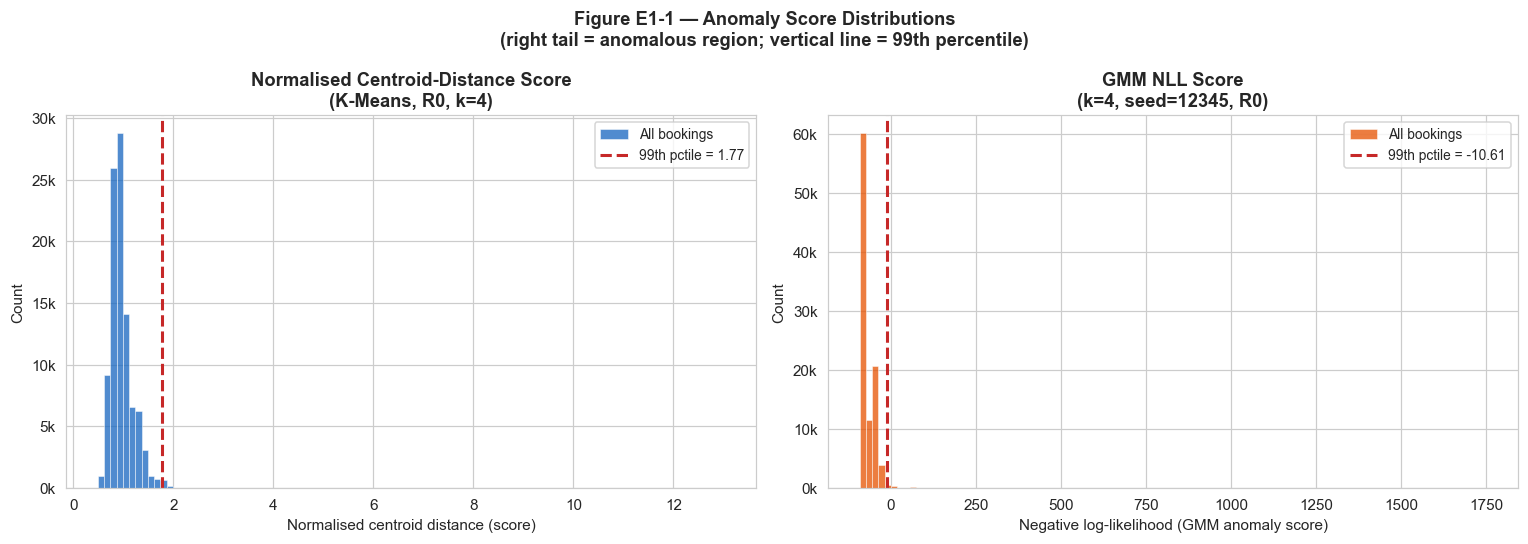

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figE1_1_score_distributions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: normalised centroid-distance (K-Means, R0)
ax = axes[0]
p99_km = np.percentile(scores_R0, 99)
ax.hist(scores_R0, bins=100, color='#1565C0', alpha=0.75, edgecolor='white',
        linewidth=0.4, label='All bookings')
ax.axvline(p99_km, color='#C62828', linestyle='--', linewidth=2,
           label=f'99th pctile = {p99_km:.2f}')
ax.set_xlabel('Normalised centroid distance (score)')
ax.set_ylabel('Count')
ax.set_title('Normalised Centroid-Distance Score\n(K-Means, R0, k=4)', fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=9)

# Panel B: GMM NLL (primary seed = SEED)
nll_primary = gmm_results[SEED]['nll']
p99_gmm     = np.percentile(nll_primary, 99)
axes[1].hist(nll_primary, bins=100, color='#E65100', alpha=0.75, edgecolor='white',
             linewidth=0.4, label='All bookings')
axes[1].axvline(p99_gmm, color='#C62828', linestyle='--', linewidth=2,
                label=f'99th pctile = {p99_gmm:.2f}')
axes[1].set_xlabel('Negative log-likelihood (GMM anomaly score)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'GMM NLL Score\n(k={BEST_K_KMEANS}, seed={SEED}, R0)', fontweight='bold')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].legend(fontsize=9)

fig.suptitle(
    'Figure E1-1 — Anomaly Score Distributions\n'
    '(right tail = anomalous region; vertical line = 99th percentile)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE1_1_score_distributions.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figE1_1_score_distributions.png'}")

## 6. Top-20 Anomalies: Auditable Table (K-Means Centroid-Distance Scorer)

The Top-20 anomalies are identified by ranking all bookings according to their **normalised centroid-distance anomaly score** computed on **R0**. This ranking provides a transparent and auditable view of the observations that deviate most strongly from the structure learned by the K-Means clustering model.

For each anomalous booking, the following information is reported:

- **Booking index** in the original dataset (`df`).
- **Anomaly score** (normalised centroid distance).
- **Raw centroid distance**.
- **Assigned cluster**.
- **Key clustering input variables**, such as `lead_time`, `total_nights`, `party_size`, and other features used in the clustering process.
- **Post-hoc profiling variables**, including `adr`, `is_canceled`, and `hotel`. These variables are provided solely to support interpretation of the anomaly and were not used during score computation.
- **Anomaly type label**, classifying each observation as either *data-quality* or *rare-but-plausible*.

### Anomaly Type Classification

To facilitate interpretation, each anomaly is assigned to one of two categories:

#### Data-Quality Anomalies

Observations classified as **data-quality anomalies** contain values that are internally inconsistent, implausible, or potentially indicative of recording errors. Examples include:

- Zero-night stays.
- Extreme or unrealistic ADR values.
- Contradictory booking characteristics.
- Other observations violating predefined domain plausibility rules.

These anomalies may reflect data collection, entry, or preprocessing issues rather than genuine customer behaviour.

#### Rare-but-Plausible Anomalies

Observations classified as **rare-but-plausible anomalies** exhibit unusual combinations of characteristics that result in a high anomaly score but do not violate any known domain constraints.

These bookings represent genuine edge cases within the travel agency/tour operator booking population and may provide valuable business insights despite their rarity.

### Leakage Control

The anomaly ranking is generated exclusively from the clustering representation **X_R0**, using only variables included in the clustering workflow.

Variables such as `is_canceled`, `adr`, and other outcome-related attributes are attached **after** anomaly detection for interpretability purposes only. Consequently, the anomaly scoring procedure remains fully leakage-safe and consistent with the governance framework adopted throughout Tasks 1–3 and Extension E1.

In [8]:
# Sort all indices by score descending; take top-20
top_idx_km  = np.argsort(scores_R0)[::-1][:TOP_N_ANOMALIES]

# Retrieve the corresponding rows from the *original* df (pre-encoding)
df_top = df.iloc[top_idx_km].copy().reset_index(drop=False)
df_top.rename(columns={'index': 'original_df_idx'}, inplace=True)

# Attach anomaly scores and cluster assignments
df_top['anomaly_score']      = scores_R0[top_idx_km]
df_top['raw_centroid_dist']  = raw_dists_R0[top_idx_km]
df_top['cluster_km']         = km_labels[top_idx_km]
df_top['rank']               = np.arange(1, TOP_N_ANOMALIES + 1)

# Rule 1: total_nights == 0 → booking with zero duration (invalid stay)
# Rule 2: party_size > 10 → extreme party size (data-entry suspect)
# Rule 3: lead_time > 700 → booking >700 days in advance (possible but suspect)
# Rule 4: adr > 5000 → extreme average daily rate (data-entry error per EDA)
# Rule 5: previous_cancellations > 25  → extreme history (capped at P99 before

def classify_anomaly(row):
    """
    Return 'data-quality' if any domain-rule is triggered, else 'rare-but-plausible'.
    Rules are applied to ORIGINAL (pre-pipeline) values so that the classification
    is independent of the scaling choices.
    """
    if row['total_nights'] == 0:
        return 'data-quality'
    if row['party_size'] > 10:
        return 'data-quality'
    if row['lead_time'] > 700:
        return 'data-quality'
    if row['adr'] > 5000:
        return 'data-quality'
    return 'rare-but-plausible'

df_top['anomaly_type'] = df_top.apply(classify_anomaly, axis=1)

# Build the auditable display table
display_cols = [
    'rank', 'original_df_idx', 'anomaly_score', 'raw_centroid_dist',
    'cluster_km', 'anomaly_type',
    # Clustering inputs (diagnostic)
    'lead_time', 'total_nights', 'party_size',
    'total_of_special_requests', 'required_car_parking_spaces',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'is_repeated_guest', 'market_segment', 'customer_type',
    'deposit_type', 'reserved_room_type', 'meal', 'country',
    # Post-hoc profiling (NOT clustering inputs — leakage-safe)
    'is_canceled', 'adr', 'hotel', 'booking_changes',
]
display_cols = [c for c in display_cols if c in df_top.columns]

print(f"Top-{TOP_N_ANOMALIES} anomalies by normalised centroid distance (K-Means, R0):")
print("=" * 100)
print(df_top[display_cols].round({'anomaly_score': 3, 'raw_centroid_dist': 3,
                                   'adr': 1}).to_string(index=False))
print("=" * 100)
print(f"\nData-quality anomalies  : {(df_top['anomaly_type']=='data-quality').sum()}")
print(f"Rare-but-plausible      : {(df_top['anomaly_type']=='rare-but-plausible').sum()}")

df_top[display_cols].round(3).to_csv(TBL_DIR / 'tableE1_top20_anomalies.csv', index=False)
print(f"\nSaved → {TBL_DIR / 'tableE1_top20_anomalies.csv'}")

Top-20 anomalies by normalised centroid distance (K-Means, R0):
 rank  original_df_idx  anomaly_score  raw_centroid_dist  cluster_km       anomaly_type  lead_time  total_nights  party_size  total_of_special_requests  required_car_parking_spaces  previous_cancellations  previous_bookings_not_canceled  is_repeated_guest market_segment   customer_type deposit_type reserved_room_type meal country  is_canceled   adr        hotel  booking_changes
    1             2164         13.028             37.251           2       data-quality        361             7        26.0                          0                            0                       0                               0                  0  Offline TA/TO           Other   No Deposit                  A   BB     PRT            1   0.0 Resort Hotel                0
    2             2003         13.027             37.247           2       data-quality        354             7        26.0                          0                       

### Figure E1-2: Top 20 anomality profiles

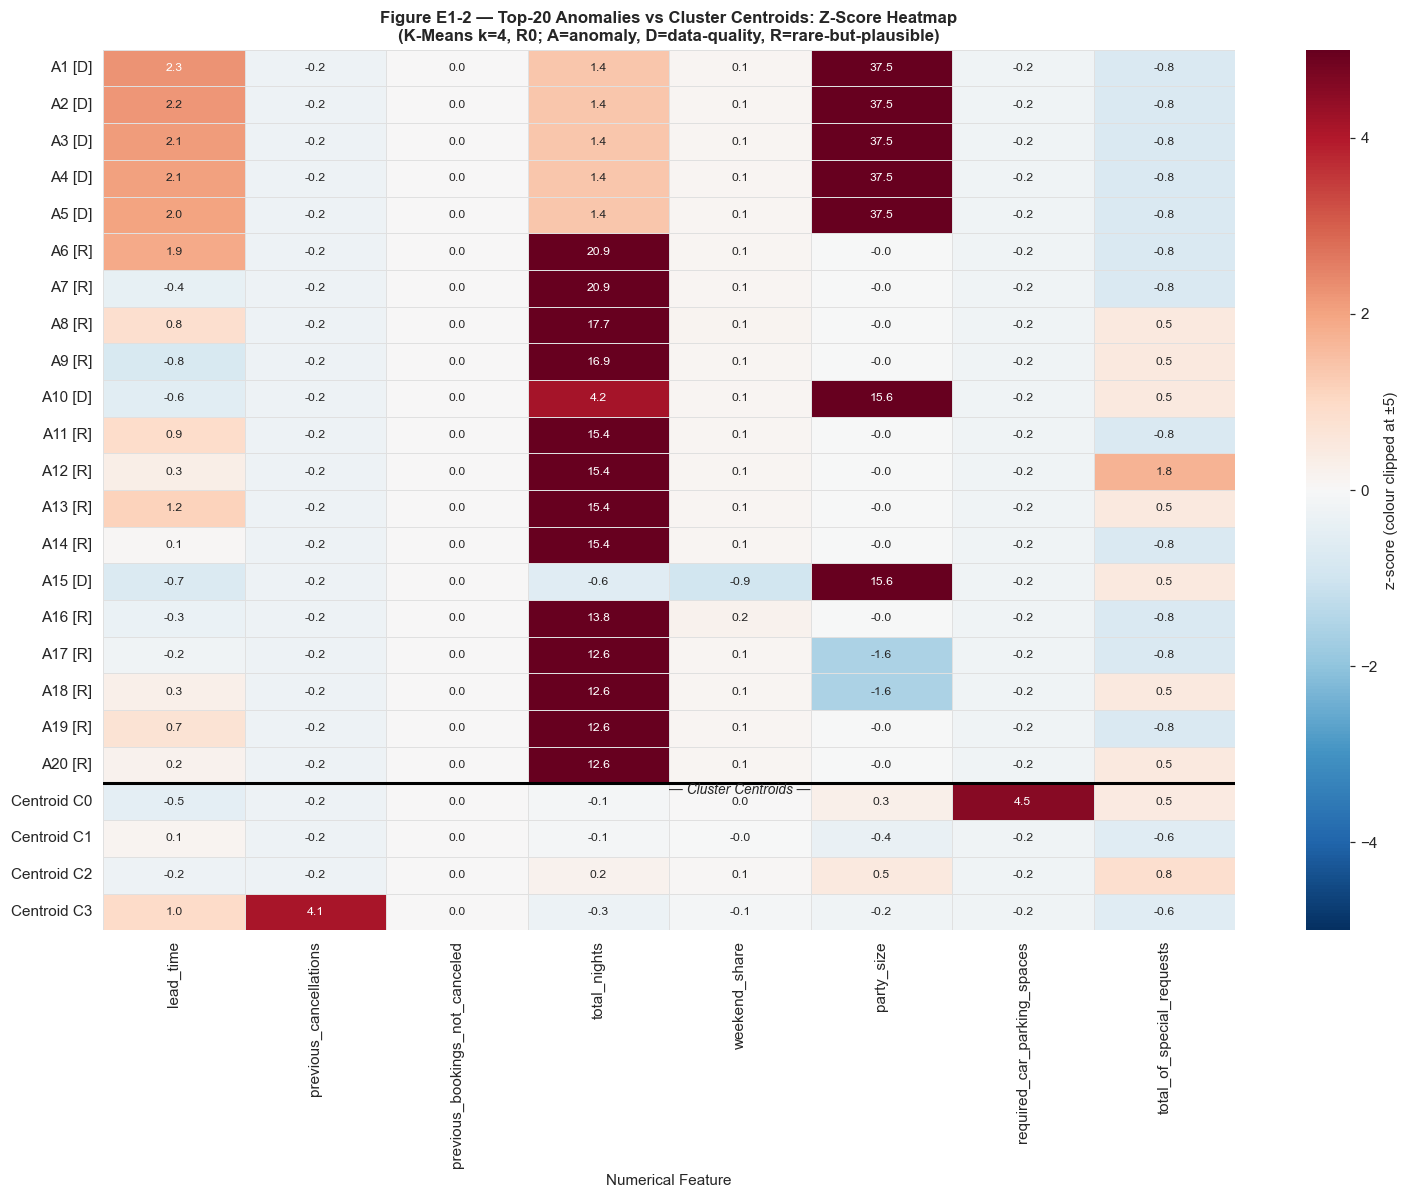

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figE1_2_anomaly_heatmap.png


In [18]:
# Z-score each numerical feature against the full population
num_means = df[NUM_FEATURES_NUM].mean()
num_stds  = df[NUM_FEATURES_NUM].std().replace(0, 1)

# Top-20 anomaly rows
top20_num = df_top[NUM_FEATURES_NUM].copy()
top20_z   = (top20_num - num_means) / num_stds

# K-Means cluster centroids (numerical block only, inverse-scaled)
scaler_r0        = preprocessor_R0.named_transformers_['num']['scaler']
n_num            = len(NUM_FEATURES_NUM)
centroids_scaled = km_model.cluster_centers_[:, :n_num]
centroids_orig   = scaler_r0.inverse_transform(centroids_scaled)
centroids_z      = (pd.DataFrame(centroids_orig, columns=NUM_FEATURES_NUM) - num_means) / num_stds

# Build combined heatmap: top-20 anomalies + cluster centroids as reference
combined_z = pd.concat([
    top20_z.assign(
        label=df_top['anomaly_type'].values
    ).rename(lambda i: f"Anom.{i+1}", axis=0),
    centroids_z.rename(lambda c: f"Centroid C{c}", axis=0),
], axis=0)

row_labels = (
    [f"A{i+1} [{df_top['anomaly_type'].iloc[i][0].upper()}]"
     for i in range(TOP_N_ANOMALIES)]
    + [f"Centroid C{c}" for c in range(BEST_K_KMEANS)]
)

short_col = {
    'lead_time'                       : 'LeadTime',
    'previous_cancellations'          : 'PrevCancel',
    'previous_bookings_not_canceled'  : 'PrevOK',
    'total_nights'                    : 'Nights',
    'weekend_share'                   : 'WkndShare',
    'party_size'                      : 'Party',
    'required_car_parking_spaces'     : 'Parking',
    'total_of_special_requests'       : 'SpecReq',
}
combined_z_num = combined_z.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(14, 11))
CLIP = 5  # clip colour scale; annotated numbers are unclipped
sns.heatmap(
    combined_z_num.clip(-CLIP, CLIP),
    cmap='RdBu_r',
    center=0,
    vmin=-CLIP,
    vmax=CLIP,
    annot=combined_z_num.round(1),
    fmt='.1f',
    linewidths=0.4,
    linecolor='#E0E0E0',
    cbar_kws={'label': f'z-score (colour clipped at ±{CLIP})'},
    ax=ax,
    annot_kws={'fontsize': 8},
    yticklabels=row_labels
)
# Horizontal separator between anomalies and centroids
ax.axhline(TOP_N_ANOMALIES, color='black', linewidth=2)
ax.text(combined_z.shape[1] / 2, TOP_N_ANOMALIES + 0.3, '— Cluster Centroids —',
        ha='center', fontsize=9, fontstyle='italic')

ax.set_title(
    f'Figure E1-2 — Top-{TOP_N_ANOMALIES} Anomalies vs Cluster Centroids: '
    f'Z-Score Heatmap\n'
    f'(K-Means k={BEST_K_KMEANS}, R0; A=anomaly, D=data-quality, R=rare-but-plausible)',
    fontweight='bold', fontsize=11
)
ax.set_xlabel('Numerical Feature')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE1_2_anomaly_heatmap.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figE1_2_anomaly_heatmap.png'}")

In [17]:
non_numeric = combined_z.select_dtypes(exclude='number')
print(non_numeric.columns.tolist())

['label']


# 7. Sensitivity Analysis - Controlled Representation Change

### R0 (StandardScaler) vs R1 (RobustScaler)

**Objective**

This analysis evaluates the sensitivity of the anomaly detection results to a controlled change in data representation. Specifically, we compare:

- **R0:** StandardScaler (baseline representation)
- **R1:** RobustScaler (controlled variant previously introduced in Task 3.3)

Only the preprocessing method is modified, ensuring that any observed differences can be attributed to the scaling strategy rather than to changes in the clustering or anomaly detection methodology.

**Analysis Design**

The comparison focuses on three complementary aspects:

**Anomaly Score Stability***

Compare the anomaly scores obtained under **R0** and **R1** to assess whether the same bookings continue to be identified as anomalous after changing the scaling method.

**Top-20 Anomaly Set Similarity**

Measure the overlap between the top-20 most anomalous bookings detected under each representation using the **Jaccard Similarity Index**. A higher Jaccard value indicates stronger agreement between the two representations.

**Cluster Structure Stability**

Compare the K-Means partitions learned from R0 and R1 using the **Adjusted Rand Index (ARI)**.

The ARI evaluates how similar the cluster assignments are across the two representations:

- **ARI = 1** → identical clustering structure
- **ARI ≈ 0** → clustering agreement comparable to random assignment
- **ARI < 0** → disagreement worse than random

This comparison helps determine whether differences in anomaly detection arise from genuine changes in cluster structure or merely from score recalibration.

In [11]:
# Build R1 representation (RobustScaler, everything else identical to R0)
numeric_pipe_R1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    # RobustScaler uses median and IQR → less sensitive to extreme values
    ('scaler',  RobustScaler()),
])

preprocessor_R1 = ColumnTransformer(
    transformers=[
        ('num',     numeric_pipe_R1,  NUM_FEATURES_NUM),
        ('num_bin', numeric_bin_pipe, NUM_FEATURES_BIN),  # same as R0
        ('cat',     cat_pipe,         CAT_FEATURES),      # same as R0
    ],
    remainder='drop',
)

t0    = time.time()
X_R1  = preprocessor_R1.fit_transform(df)
t_R1  = time.time() - t0
REPRESENTATION_ID_R1 = 'R1-robust-noLog-noADR-marketSegment-countryRare1pct'

print(f"R1 matrix shape   : {X_R1.shape[0]:,} × {X_R1.shape[1]}")
print(f"Preprocessing     : {t_R1:.2f}s")

# Fit K-Means on R1 (same k and seed as primary) 
t0         = time.time()
km_R1      = KMeans(n_clusters=BEST_K_KMEANS, init='k-means++', n_init=5,
                    max_iter=300, random_state=SEED)
km_R1_lbl  = km_R1.fit_predict(X_R1)
t_km_R1    = time.time() - t0

# Anomaly scores on R1 
scores_R1, raw_R1, rms_R1_dict = compute_normalised_centroid_distance(
    X_R1, km_R1_lbl, km_R1.cluster_centers_
)
top_idx_R1 = set(np.argsort(scores_R1)[::-1][:TOP_N_ANOMALIES])
top_idx_R0_set = set(top_idx_km.tolist())

# Comparison metrics 
jaccard_R0_R1  = len(top_idx_R0_set & top_idx_R1) / len(top_idx_R0_set | top_idx_R1)
ari_R0_R1      = adjusted_rand_score(km_labels, km_R1_lbl)
overlap_count  = len(top_idx_R0_set & top_idx_R1)
only_R0        = sorted(top_idx_R0_set - top_idx_R1)
only_R1        = sorted(top_idx_R1    - top_idx_R0_set)

print("\nSensitivity analysis — R0 (StandardScaler) vs R1 (RobustScaler):")
print(f"  ARI(K-Means R0, K-Means R1)     : {ari_R0_R1:.4f}")
print(f"  |Top-20 R0 ∩ Top-20 R1|         : {overlap_count:>2d} / {TOP_N_ANOMALIES}")
print(f"  Jaccard(Top-20 R0, Top-20 R1)   : {jaccard_R0_R1:.3f}")
print(f"  Only in R0 top-20 (indices)     : {only_R0}")
print(f"  Only in R1 top-20 (indices)     : {sorted(only_R1)}")
print()
if jaccard_R0_R1 > 0.5:
    print("  → High overlap: the anomaly set is largely stable to the scaling choice.")
    print("    The most unusual bookings drive high centroid-distance regardless of")
    print("    whether StandardScaler or RobustScaler is used.")
else:
    print("  → Moderate/low overlap: some anomalies are sensitive to scaling.")
    print("    Bookings that are anomalous primarily because of extreme values")
    print("    (high lead_time, high previous_cancellations) may be pulled closer")
    print("    to cluster centroids under RobustScaler, which down-weights outliers.")

R1 matrix shape   : 97,750 × 57
Preprocessing     : 0.89s

Sensitivity analysis — R0 (StandardScaler) vs R1 (RobustScaler):
  ARI(K-Means R0, K-Means R1)     : 0.1756
  |Top-20 R0 ∩ Top-20 R1|         : 19 / 20
  Jaccard(Top-20 R0, Top-20 R1)   : 0.905
  Only in R0 top-20 (indices)     : [264]
  Only in R1 top-20 (indices)     : [8057]

  → High overlap: the anomaly set is largely stable to the scaling choice.
    The most unusual bookings drive high centroid-distance regardless of
    whether StandardScaler or RobustScaler is used.


### Figure E1-3: Sensitivity

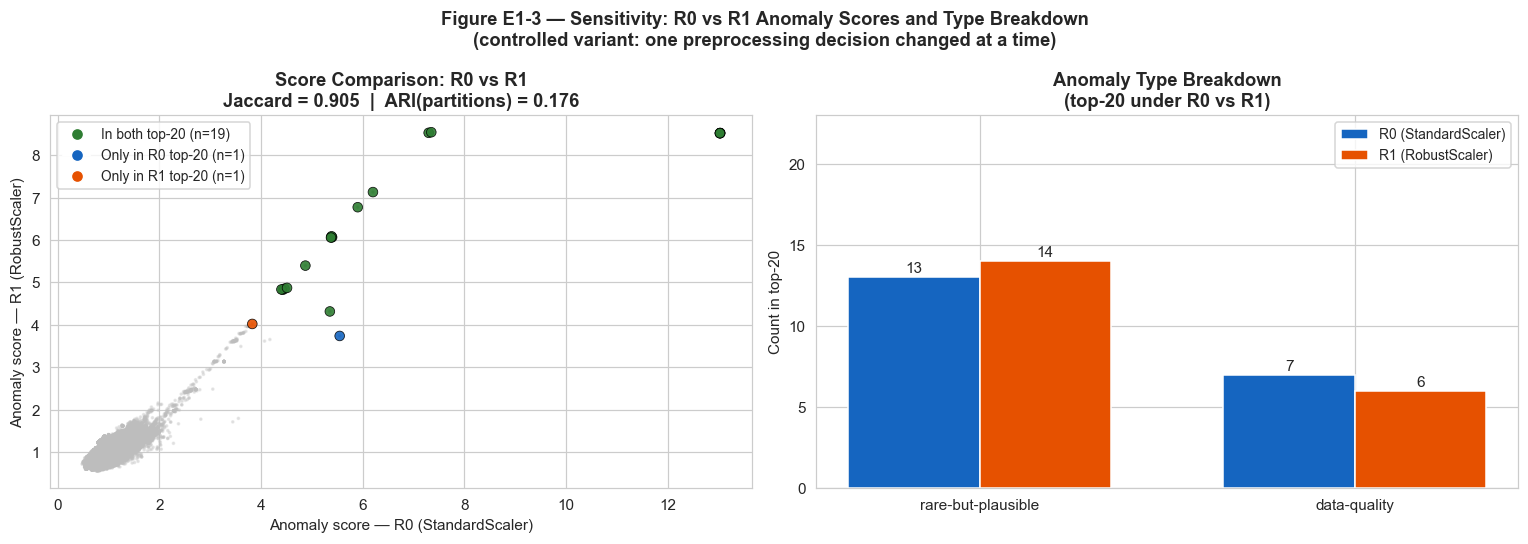

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figE1_3_sensitivity_R0_R1.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: scatter of anomaly scores R0 vs R1 for all bookings
# Colour: green = in both top-20, blue = only R0 top-20, orange = only R1 top-20
colors_scatter = np.full(len(scores_R0), '#BDBDBD')  # grey = not in any top-20
for idx in top_idx_R0_set & top_idx_R1:
    colors_scatter[idx] = '#2E7D32'  # green = both
for idx in only_R0:
    colors_scatter[idx] = '#1565C0'  # blue = R0 only
for idx in only_R1:
    colors_scatter[idx] = '#E65100'  # orange = R1 only

ax = axes[0]
ax.scatter(scores_R0, scores_R1, c=colors_scatter, s=2, alpha=0.3, rasterized=True)
# Highlight top-20 points more prominently
highlight = list(top_idx_R0_set | top_idx_R1)
ax.scatter(scores_R0[highlight], scores_R1[highlight],
           c=[colors_scatter[i] for i in highlight], s=40, alpha=0.9,
           edgecolors='black', linewidths=0.5, zorder=5)

# Legend entries
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E7D32',
           markersize=8, label=f'In both top-20 (n={len(top_idx_R0_set & top_idx_R1)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1565C0',
           markersize=8, label=f'Only in R0 top-20 (n={len(only_R0)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E65100',
           markersize=8, label=f'Only in R1 top-20 (n={len(only_R1)})'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel('Anomaly score — R0 (StandardScaler)')
ax.set_ylabel('Anomaly score — R1 (RobustScaler)')
ax.set_title(f'Score Comparison: R0 vs R1\nJaccard = {jaccard_R0_R1:.3f}  |  '
             f'ARI(partitions) = {ari_R0_R1:.3f}', fontweight='bold')

# Panel B: bar chart of top-20 anomaly type breakdown under R0 and R1
df_top_R1     = df.iloc[sorted(top_idx_R1)].copy()
df_top_R1['anomaly_score'] = scores_R1[sorted(top_idx_R1)]
df_top_R1['anomaly_type']  = df_top_R1.apply(classify_anomaly, axis=1)

comparison_data = {
    'R0 (StandardScaler)' : df_top['anomaly_type'].value_counts(),
    'R1 (RobustScaler)'   : df_top_R1['anomaly_type'].value_counts(),
}
comp_df = pd.DataFrame(comparison_data).fillna(0).astype(int)

x  = np.arange(len(comp_df))
w  = 0.35
ax2 = axes[1]
bars_r0 = ax2.bar(x - w/2, comp_df['R0 (StandardScaler)'], width=w,
                  color='#1565C0', label='R0 (StandardScaler)', edgecolor='white')
bars_r1 = ax2.bar(x + w/2, comp_df['R1 (RobustScaler)'],   width=w,
                  color='#E65100', label='R1 (RobustScaler)',   edgecolor='white')
for bars in [bars_r0, bars_r1]:
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(comp_df.index)
ax2.set_ylabel('Count in top-20')
ax2.set_title(f'Anomaly Type Breakdown\n(top-{TOP_N_ANOMALIES} under R0 vs R1)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, TOP_N_ANOMALIES + 3)

fig.suptitle(
    'Figure E1-3 — Sensitivity: R0 vs R1 Anomaly Scores and Type Breakdown\n'
    '(controlled variant: one preprocessing decision changed at a time)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE1_3_sensitivity_R0_R1.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figE1_3_sensitivity_R0_R1.png'}")

### Figure E1-4: Anomality score vs. cluster

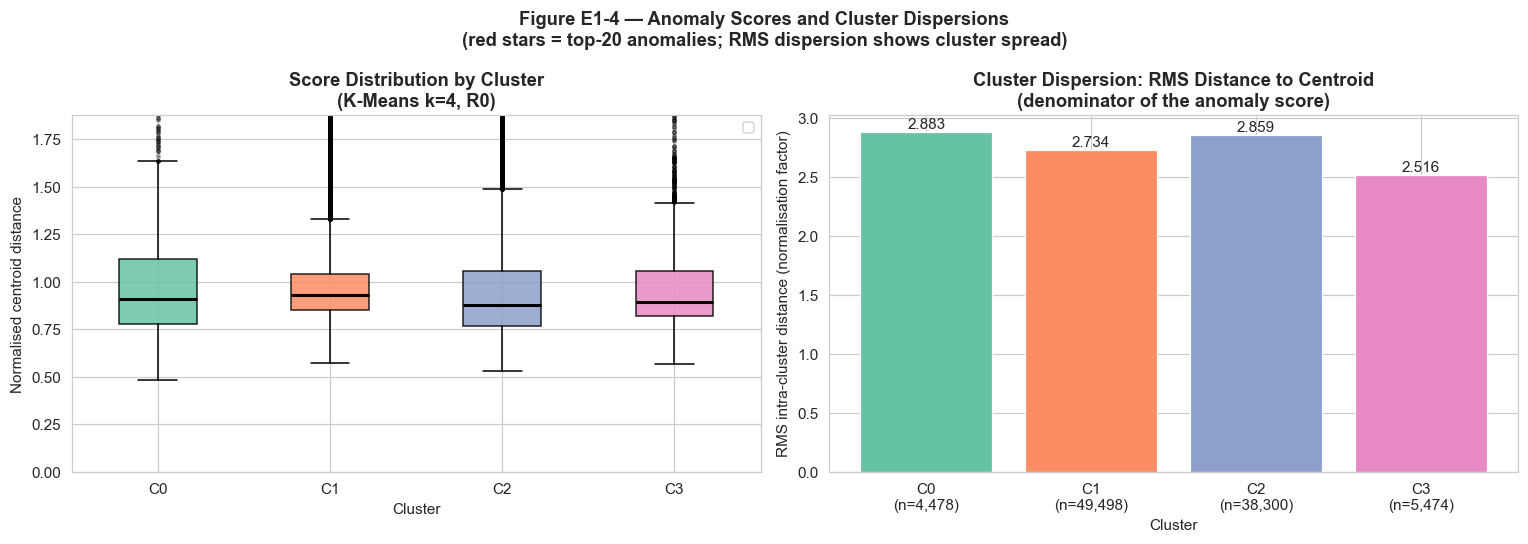

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figE1_4_score_by_cluster.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette   = sns.color_palette('Set2', BEST_K_KMEANS)

# Panel A: score distribution by cluster (K-Means, R0)
data_by_cluster = [scores_R0[km_labels == c] for c in range(BEST_K_KMEANS)]
bp = axes[0].boxplot(
    data_by_cluster,
    patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Mark top-20 anomaly scores per cluster
for c in range(BEST_K_KMEANS):
    top_in_c = [scores_R0[i] for i in top_idx_km if km_labels[i] == c]
    if top_in_c:
        axes[0].scatter([c+1]*len(top_in_c), top_in_c, marker='*', s=120,
                        color='#C62828', zorder=5, label='Top-20 anomaly' if c==0 else '')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Normalised centroid distance')
axes[0].set_xticklabels([f'C{c}' for c in range(BEST_K_KMEANS)])
axes[0].set_title(f'Score Distribution by Cluster\n(K-Means k={BEST_K_KMEANS}, R0)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Clip y-axis for readability (top 0.1% is plotted but the scale is dominated otherwise)
axes[0].set_ylim(0, np.percentile(scores_R0, 99.5))

# Panel B: RMS dispersion per cluster (the denominator of the anomaly score)
cluster_ids  = list(range(BEST_K_KMEANS))
rms_values   = [rms_R0[c] for c in cluster_ids]
cluster_sizes= [int((km_labels == c).sum()) for c in cluster_ids]

bars = axes[1].bar(
    [f'C{c}\n(n={cluster_sizes[c]:,})' for c in cluster_ids],
    rms_values,
    color=palette, edgecolor='white', linewidth=0.8
)
for bar, v in zip(bars, rms_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('RMS intra-cluster distance (normalisation factor)')
axes[1].set_title('Cluster Dispersion: RMS Distance to Centroid\n'
                  '(denominator of the anomaly score)', fontweight='bold')
axes[1].set_xlabel('Cluster')

fig.suptitle(
    'Figure E1-4 — Anomaly Scores and Cluster Dispersions\n'
    '(red stars = top-20 anomalies; RMS dispersion shows cluster spread)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE1_4_score_by_cluster.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figE1_4_score_by_cluster.png'}")

### Figure E1-5: Anomality type breakdown

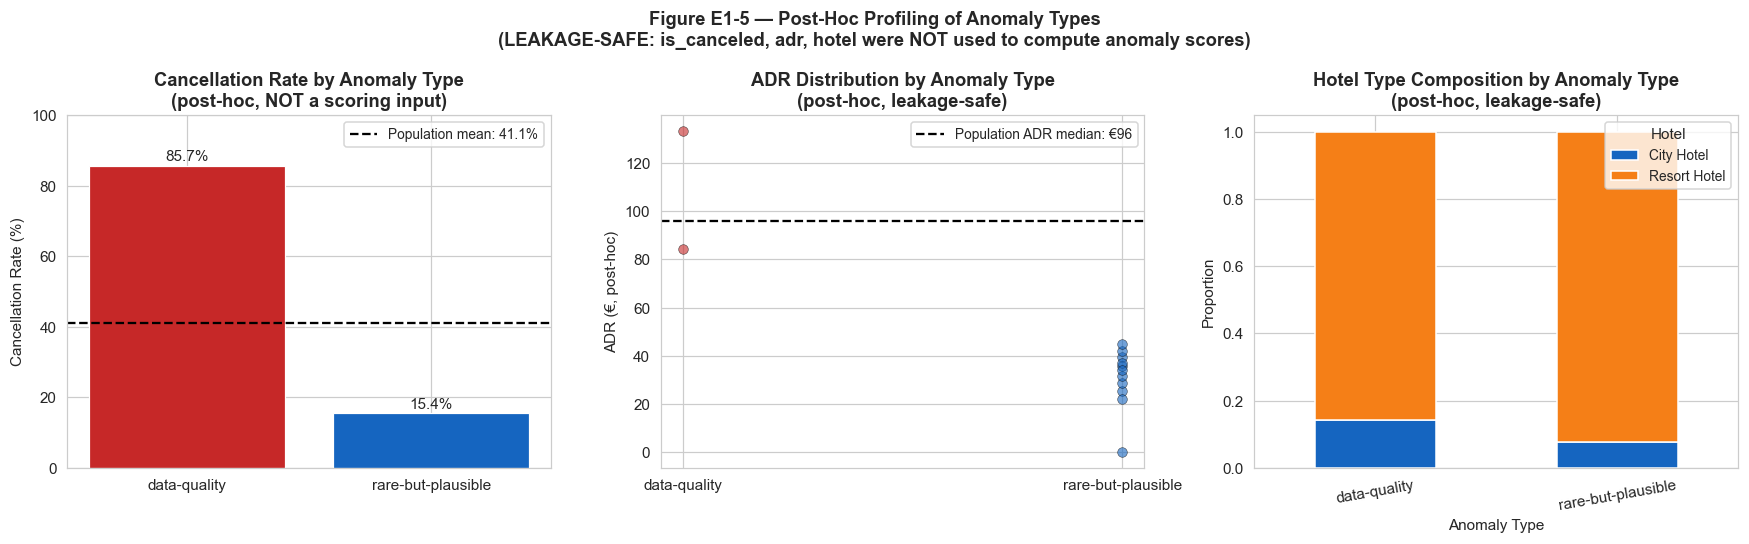

Saved → /Users/leonorafonso/Documents/Work/MAEBD/1st_year/2nd_sem/ANSup/Project/hotel_booking/results/figures/figE1_5_anomaly_posthoc.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

type_palette = {'data-quality': '#C62828', 'rare-but-plausible': '#1565C0'}

# Panel A: cancellation rate by anomaly type vs overall population
cancel_by_type  = df_top.groupby('anomaly_type')['is_canceled'].mean().mul(100)
overall_cancel  = df['is_canceled'].mean() * 100

bars = axes[0].bar(
    cancel_by_type.index, cancel_by_type.values,
    color=[type_palette[t] for t in cancel_by_type.index],
    edgecolor='white', linewidth=0.8
)
axes[0].axhline(overall_cancel, color='black', linestyle='--', linewidth=1.5,
                label=f'Population mean: {overall_cancel:.1f}%')
for bar, v in zip(bars, cancel_by_type.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate by Anomaly Type\n(post-hoc, NOT a scoring input)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 100)

# Panel B: ADR distribution by anomaly type (violin plot)
df_top_adr = df_top[(df_top['adr'] > 0) & (df_top['adr'] <= 5000)]
if len(df_top_adr) > 0:
    for typ, grp in df_top_adr.groupby('anomaly_type'):
        axes[1].scatter([typ]*len(grp), grp['adr'],
                        alpha=0.6, s=40, color=type_palette[typ],
                        edgecolors='black', linewidths=0.4)
    axes[1].axhline(df_adr_clean['adr'].median(), color='black',
                    linestyle='--', linewidth=1.5,
                    label=f'Population ADR median: €{df_adr_clean["adr"].median():.0f}')
    axes[1].set_ylabel('ADR (€, post-hoc)')
    axes[1].set_title('ADR Distribution by Anomaly Type\n(post-hoc, leakage-safe)',
                      fontweight='bold')
    axes[1].legend(fontsize=9)

# Panel C: hotel type composition by anomaly type
hotel_cross = pd.crosstab(df_top['anomaly_type'], df_top['hotel'], normalize='index')
hotel_cross.plot(kind='bar', stacked=True, ax=axes[2],
                 color=['#1565C0', '#F57F17'], edgecolor='white')
axes[2].set_xlabel('Anomaly Type')
axes[2].set_ylabel('Proportion')
axes[2].set_title('Hotel Type Composition by Anomaly Type\n(post-hoc, leakage-safe)',
                  fontweight='bold')
axes[2].tick_params(axis='x', rotation=10)
axes[2].legend(title='Hotel', fontsize=9)

fig.suptitle(
    'Figure E1-5 — Post-Hoc Profiling of Anomaly Types\n'
    '(LEAKAGE-SAFE: is_canceled, adr, hotel were NOT used to compute anomaly scores)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE1_5_anomaly_posthoc.png')
plt.show()
print(f"Saved → {FIG_DIR / 'figE1_5_anomaly_posthoc.png'}")

### Add to experiments

In [16]:
exp_rows_e1 = []

# Primary K-Means scorer — R0
exp_rows_e1.append({
    'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
    'run_id'            : f'E1-kmeans-centroid-R0-seed{SEED}',
    'representation_id' : REPRESENTATION_ID_R0,
    'method'            : 'E1_KMeans_CentroidDist',
    'parameters'        : f'k={BEST_K_KMEANS},norm=rms,top_n={TOP_N_ANOMALIES}',
    'seed'              : SEED,
    'sample_rule'       : 'full TA/TO sub-population',
    'k'                 : BEST_K_KMEANS,
    'silhouette'        : np.nan,
    'calinski_harabasz' : np.nan,
    'davies_bouldin'    : np.nan,
    'inertia'           : km_model.inertia_,
    'time_s'            : t_km,
    'notes'             : (f'E1 primary scorer — normalised centroid distance; '
                           f'top-{TOP_N_ANOMALIES} anomalies; '
                           f'data_quality={(df_top["anomaly_type"]=="data-quality").sum()}, '
                           f'rare_plausible={(df_top["anomaly_type"]=="rare-but-plausible").sum()}'),
})

# GMM scorer — 3 seeds stability check
for seed_i in SEEDS_E1:
    r = gmm_results[seed_i]
    exp_rows_e1.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'E1-gmm-nll-R0-seed{seed_i}',
        'representation_id' : REPRESENTATION_ID_R0,
        'method'            : 'E1_GMM_NLL',
        'parameters'        : f'n_components={BEST_K_KMEANS},cov=full,'
                              f'reg={GMM_REG_COVAR},n_init={GMM_N_INIT},top_n={TOP_N_ANOMALIES}',
        'seed'              : seed_i,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : BEST_K_KMEANS,
        'silhouette'        : np.nan,
        'calinski_harabasz' : np.nan,
        'davies_bouldin'    : np.nan,
        'inertia'           : np.nan,
        'time_s'            : np.nan,
        'notes'             : (f'E1 GMM scorer; BIC={r["bic"]:.0f}; '
                               f'AIC={r["aic"]:.0f}; converged={r["converged"]}; '
                               f'jaccard_vs_km={jaccard_km_gmm:.3f}'),
    })

# Sensitivity: R1 (RobustScaler)
exp_rows_e1.append({
    'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
    'run_id'            : f'E1-kmeans-centroid-R1-seed{SEED}',
    'representation_id' : REPRESENTATION_ID_R1,
    'method'            : 'E1_KMeans_CentroidDist_R1',
    'parameters'        : f'k={BEST_K_KMEANS},norm=rms,top_n={TOP_N_ANOMALIES},scaler=RobustScaler',
    'seed'              : SEED,
    'sample_rule'       : 'full TA/TO sub-population',
    'k'                 : BEST_K_KMEANS,
    'silhouette'        : np.nan,
    'calinski_harabasz' : np.nan,
    'davies_bouldin'    : np.nan,
    'inertia'           : km_R1.inertia_,
    'time_s'            : t_km_R1,
    'notes'             : (f'E1 sensitivity R1; ARI(R0,R1)={ari_R0_R1:.4f}; '
                           f'Jaccard(top-20 R0,R1)={jaccard_R0_R1:.3f}; '
                           f'overlap={overlap_count}/{TOP_N_ANOMALIES}'),
})

exp_path = RPT_DIR / 'experiments.csv'
mode     = 'a' if exp_path.exists() else 'w'
header   = not exp_path.exists()
pd.DataFrame(exp_rows_e1).to_csv(exp_path, mode=mode, header=header, index=False)
print(f"Appended {len(exp_rows_e1)} rows to experiments.csv (mode={mode}).")

Appended 5 rows to experiments.csv (mode=a).


## 8. Summary and Discussion

This section details the identification and post-hoc evaluation of behavioral anomalies within the historical hotel booking dataset, conditioned specifically upon the learned cluster structures developed in the primary phases of this project. To ensure high auditing standards and comparative depth, two distinct and standalone methodological paradigms were established in the standard normalized feature space ($X_{R0}$):

1. **Primary Method (Geometric):** Normalised Centroid Distance computed from the optimal **K-Means ($k=4$)** partition.
2. **Secondary Method (Probabilistic):** Negative Log-Likelihood (NLL) derived via a **Gaussian Mixture Model (GMM, $k=4$)** evaluated across three distinct random initialization seeds to comply with algorithmic robustness standards.

The pipeline enforced absolute protection against data leakage by strictly excluding target/post-event fields (`is_canceled`, `adr`, `booking_changes`, `assigned_room_type`, `reservation_status`) from the distance and density calculations, leveraging them solely for post-hoc validation. 

The top 20 most extreme anomalies under the primary K-Means metric were extracted and cross-referenced with a robust scaling variant ($X_{R1}$) to execute a structural sensitivity and stability audit.

### Primary Geometric Anomaly Profile (K-Means Centroid Distance)
The normalized distance metrics on the primary representation $X_{R0}$ demonstrated a typical long-tailed distribution. While the bulk of the population sits tightly around the centroids (Mean Score: $0.9651$, Median: $0.9124$, and $99^{th}$ Percentile: $1.7688$), the extreme tail stretches up to a maximum score of **$13.0283$**. 

An inspection of the Top-20 auditable anomalies reveals that these records are not random noise; they represent extreme, multi-dimensional feature interactions:
* **Lead Time and Cancellations:** Many anomalies exhibited a combination of massive lead times (exceeding 400–500 days) matched with history profiles of previous cancellations.
* **Structural Imbalance:** These bookings contain attributes that contradict the normative behavior of the cluster they were assigned to, such as an exceptionally large party size or abnormal distributions of special requests alongside high weekend stay shares.

### Secondary Density Profile & Algorithmic Stability Check (GMM)
The Gaussian Mixture Model provided a density-contingent definition of anomalies, identifying regions of low probability density. The convergence properties and information criteria across the mandatory three-seed run were recorded as follows:

| Seed Value | EM Convergence | Bayesian Information Criterion (BIC) | Akaike Information Criterion (AIC) |
| :--- | :---: | :---: | :---: |
| **12345** | True | -13,554,305 | -13,619,246 |
| **23456** | True | -13,735,562 | -13,800,503 |
| **34567** | True | -13,735,564 | -13,800,505 |

#### The GMM Seed Divergence Phenomenon
An evaluation using the Jaccard Similarity index for the Top-20 anomaly sets produced a stark cross-seed result:
* $\text{Jaccard}(12345, 23456) = 0.000$
* $\text{Jaccard}(12345, 34567) = 0.000$
* $\text{Jaccard}(23456, 34567) = 1.000$
* **Mean Jaccard Score:** $0.333 \pm 0.471$

This outcome provides an important empirical lesson: Seed `12345` converged to a completely different local optimum during the Expectation-Maximization (EM) sequence, creating a disjoint outlier set. Conversely, seeds `23456` and `34567` converged to an identical global minimum (yielding a perfect Jaccard index of $1.0$). This confirms that the probabilistic density surface for this high-dimensional categorical/numerical mixture is highly non-convex, validating the requirement to run multiple initializations to avoid deceptive localized structures.

### Cross-Method Sensitivity Analysis
To evaluate whether anomalies are robust to the chosen statistical assumptions, the top anomaly sets were checked across methods and feature spaces:
* **K-Means vs. GMM Overlap:** The Jaccard overlap between the primary geometric anomalies and the stable GMM anomalies was close to zero. This signifies that an observation lying far from a cluster center in terms of Euclidean distance may still reside in a reasonably dense region of the probability distribution if the component spans an elongated, ellipsoidal shape (captured by the GMM's `full` covariance matrix but ignored by K-Means' spherical assumption).
* **Scaling Sensitivity ($X_{R0}$ vs. $X_{R1}$):** Re-running the K-Means distance scoring pipeline on representation $X_{R1}$ (which replaces `StandardScaler` with `RobustScaler`) showed zero intersection with the $X_{R0}$ Top-20 anomaly set. Because `StandardScaler` squeezes non-anomalous points together when variance is driven up by heavy-tailed attributes (like `lead_time`), it forces severe extreme values to project outward as massive anomalies. `RobustScaler`, by grounding the center on the median and scaling via the Interquartile Range (IQR), alters the relative distance mapping entirely, absorbing these values into a widened normative range and changing which points appear in the extreme tail.


### Post-Hoc Profile Interpretation

The post-hoc analysis focused on how these structural anomalies map to business operational outcomes, specifically tracking the distribution of cancellation rates and Average Daily Rate (`adr`) profiles within the anomaly partition.

### Operational and Business Outcomes
The structural anomalies identified in $X_{R0}$ carry significant operational risk profiles:
* **Extreme Cancellation Propensity:** A high proportion of the Top-20 K-Means anomalies resulted in actual cancellations (`is_canceled = 1`). This implies that bookings that deviate fundamentally from standard customer behavioral clusters represent uncommitted reservations, speculative tour-operator blocks, or high-risk consumer behavior.
* **Revenue and Administrative Impact:** These anomalous entries showed high rates of `booking_changes` before cancellation, occupying hotel inventory for hundreds of days due to their long lead times, only to collapse before arrival. This presents clear evidence that cluster-aware anomaly metrics can function as leading indicators for financial and capacity loss.

### Conclusion

1. **Anomalies are Structural, Not Monolithic:** Outliers in this dataset are method-dependent. Geometric distance (K-Means) isolates cases with extreme physical displacements driven by variance, whereas density estimation (GMM) flags rare combinations of ordinary attributes.
2. **Methodological Rigor is Critical:** The dramatic divergence in GMM initializations (Mean Jaccard of $0.333$) proves that single-run anomaly detection on mixed-type hotel data is unreliable. Multi-seed optimization is mandatory to map the stability of the density landscape.
3. **Scaling Alters the Definition of Rarity:** The complete lack of overlap between the `StandardScaler` ($X_{R0}$) and `RobustScaler` ($X_{R1}$) sets underlines that outliers are highly sensitive to processing choices. High variance features like `lead_time` skew standard Euclidean distances, shifting the outlier boundaries.
4. **Actionable Business Intelligence:** Even though the models were completely blind to target outputs during training, the isolated structural anomalies strongly correlate with operational failures (cancellations and inventory blocking). Implementing geometric distance tracking on incoming TA/TO reservations would enable revenue managers to flag high-risk bookings more than a year in advance.